In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install fredapi xgboost lightgbm statsmodels category_encoders
!pip install fredapi pandas matplotlib

from fredapi import Fred # Federal Reserve Economic Data
import pandas as pd
import seaborn as sns
from google.colab import userdata
fred = Fred(api_key=userdata.get('FRED_API_KEY'))


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.5 MB/s eta 0:00:00


In [ ]:
'''import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. FETCH DATA
series_to_pull = {
    'Unemployment': 'UNRATE',    # Monthly
    'Inflation': 'CPIAUCSL',      # Monthly
    'Weekly_Claims': 'ICSA',      # Weekly Leading Indicator
}

raw_data = {}
for name, s_id in series_to_pull.items():
    raw_data[name] = fred.get_series(s_id)

df = pd.DataFrame(raw_data)

# 2. ALIGNMENT (Resampling)
# Weekly_Claims is weekly; others are monthly. We convert all to Monthly Start (MS)
# We use .mean() to aggregate weekly data and .ffill() to handle the "delay" in reporting.
df_clean = df.resample('MS').mean().ffill().dropna()

# 3. FEATURE ENGINEERING

# FIX: Convert CPI Index to Inflation Rate (Year-over-Year or Month-over-Month)
# We use pct_change(12) for Year-over-Year inflation, which is the standard metric (e.g., "Inflation is 3%")
df_clean['Inflation_Rate'] = df_clean['Inflation'].pct_change(12) * 100

# Now create your Lags based on the RATE, not the Index
df_clean['Claims_Lag1'] = df_clean['Weekly_Claims'].shift(1)
df_clean['Inflation_Lag1'] = df_clean['Inflation_Rate'].shift(1)

# Drop NaN values created by the shifting/pct_change
df_clean = df_clean.dropna()

# Normalize Features (Z-Score)
df_clean['Unemployment_Z'] = (df_clean['Unemployment'] - df_clean['Unemployment'].mean()) / df_clean['Unemployment'].std()
df_clean['Claims_Z'] = (df_clean['Weekly_Claims'] - df_clean['Weekly_Claims'].mean()) / df_clean['Weekly_Claims'].std()

# 4. VISUALIZATION
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# Chart 1: Time Series Comparison
sns.lineplot(data=df_clean[['Unemployment_Z', 'Claims_Z']], ax=ax1)
ax1.set_title("Unemployment vs. Weekly Claims (Lagged)", fontsize=15)
ax1.set_ylabel("Rate / Count")

# Chart 2: Correlation Heatmap
# This tells you which indicators are actually useful for your model
cols_to_show = ['Unemployment_Z', 'Claims_Z', 'Claims_Lag1', 'Inflation']

sns.heatmap(df_clean[cols_to_show].corr(), annot=True, cmap='coolwarm', center=0, ax=ax2)
ax2.set_title("Correlation Heatmap: Macro Indicators", fontsize=15)

plt.tight_layout()
plt.show()


# 1970-2010 Graph
df_historical = df_clean.loc['1970-01-01':'2010-12-31'].copy()

df_historical['Unemployment_Z'] = (df_historical['Unemployment'] - df_historical['Unemployment'].mean()) / df_historical['Unemployment'].std()
df_historical['Claims_Z'] = (df_historical['Weekly_Claims'] - df_historical['Weekly_Claims'].mean()) / df_historical['Weekly_Claims'].std()

# 3. Visualization
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# Line Chart: Historical Comparison
sns.lineplot(data=df_historical[['Unemployment_Z', 'Claims_Z']], ax=ax1)
ax1.set_title("Historical Nowcast: 1970 - 2010", fontsize=15)
ax1.set_ylabel("Standard Deviations from Mean")

# Correlation Heatmap for this specific period
sns.heatmap(df_historical[['Unemployment', 'Weekly_Claims', 'Inflation']].corr(),
            annot=True, cmap='coolwarm', center=0, ax=ax2)
ax2.set_title("Correlation Matrix: 1970 - 2010", fontsize=15)

plt.tight_layout()
plt.show()
'''

'import matplotlib.pyplot as plt\nimport seaborn as sns\nimport pandas as pd\n\n# 1. FETCH DATA\nseries_to_pull = {\n    \'Unemployment\': \'UNRATE\',    # Monthly\n    \'Inflation\': \'CPIAUCSL\',      # Monthly\n    \'Weekly_Claims\': \'ICSA\',      # Weekly Leading Indicator\n}\n\nraw_data = {}\nfor name, s_id in series_to_pull.items():\n    raw_data[name] = fred.get_series(s_id)\n\ndf = pd.DataFrame(raw_data)\n\n# 2. ALIGNMENT (Resampling)\n# Weekly_Claims is weekly; others are monthly. We convert all to Monthly Start (MS)\n# We use .mean() to aggregate weekly data and .ffill() to handle the "delay" in reporting.\ndf_clean = df.resample(\'MS\').mean().ffill().dropna()\n\n# 3. FEATURE ENGINEERING\n\n# FIX: Convert CPI Index to Inflation Rate (Year-over-Year or Month-over-Month)\n# We use pct_change(12) for Year-over-Year inflation, which is the standard metric (e.g., "Inflation is 3%")\ndf_clean[\'Inflation_Rate\'] = df_clean[\'Inflation\'].pct_change(12) * 100\n\n# Now create your 

In [ ]:
#Data Fetching & Processing
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
fred = Fred(api_key=userdata.get('FRED_API_KEY'))

# 1. FETCH DATA
series_to_pull = {
    'Unemployment': 'UNRATE',     # Monthly Target
    'Inflation': 'CPIAUCSL',      # Monthly Target
    'Weekly_Claims': 'ICSA',      # Weekly Leading Indicator
    'Personal_Income': 'W875RX1'  # Monthly Proxy
}

raw_data = {}
for name, s_id in series_to_pull.items():
    print(f"Fetching {name}...")
    raw_data[name] = fred.get_series(s_id)

df = pd.DataFrame(raw_data)

# 2. ALIGNMENT
# Weekly_Claims is weekly, others are monthly. Convert all to Monthly Start (MS)
df_clean = df.resample('MS').mean().ffill().dropna()


# 3. FEATURE ENGINEERING

# TRANSFORMATION 1: Inflation (CPI Index -> Year-over-Year Growth Rate)
df_clean['Inflation_Rate'] = df_clean['Inflation'].pct_change(12) * 100

# TRANSFORMATION 2: Income (Raw Income -> Year-over-Year Growth Rate)
df_clean['Income_Growth'] = df_clean['Personal_Income'].pct_change(12) * 100

# LAGS: Create Lags based on the RATES/COUNTS
df_clean['Claims_Lag1'] = df_clean['Weekly_Claims'].shift(1)
df_clean['Inflation_Lag1'] = df_clean['Inflation_Rate'].shift(1)
df_clean['Income_Lag1'] = df_clean['Income_Growth'].shift(1)

# Drop NaN values created by the shifting/pct_change
df_clean = df_clean.dropna()

# NORMALIZATION (Z-Scores)

cols_to_normalize = ['Unemployment', 'Weekly_Claims', 'Income_Growth']
for col in cols_to_normalize:
    df_clean[f'{col}_Z'] = (df_clean[col] - df_clean[col].mean()) / df_clean[col].std()

print("Data Processing Complete.")
print(df_clean.tail())

'''Fetches raw data, it is pre-processed, resamples weekly data to align with monthly reporting periods.
Applies statistical trasnformarions, coverting raw CPI and income indies into year-over-year growth rates.
Generates Lag feature (t-1) to enable predictive nowcasting. Lastly applies Z-score normalization to all
variables.'''

Fetching Unemployment...
Fetching Inflation...
Fetching Weekly_Claims...
Fetching Personal_Income...
Data Processing Complete.
            Unemployment  Inflation  Weekly_Claims  Personal_Income  \
2025-10-01           4.4    324.245       226750.0          16636.7   
2025-11-01           4.5    325.063       217600.0          16666.2   
2025-12-01           4.4    326.031       219000.0          16644.2   
2026-01-01           4.3    326.588       211400.0          16644.2   
2026-02-01           4.3    326.588       217500.0          16644.2   

            Inflation_Rate  Income_Growth  Claims_Lag1  Inflation_Lag1  \
2025-10-01        2.729136       0.636361     234750.0        3.022572   
2025-11-01        2.696444       0.458707     226750.0        2.729136   
2025-12-01        2.653304       0.226416     217600.0        2.696444   
2026-01-01        2.391201       0.052899     219000.0        2.653304   
2026-02-01        2.161230       0.262641     211400.0        2.391201   

 

'Fetches raw data, it is pre-processed, resamples weekly data to align with monthly reporting periods.\nApplies statistical trasnformarions, coverting raw CPI and income indies into year-over-year growth rates.\nGenerates Lag feature (t-1) to enable predictive nowcasting. Lastly applies Z-score normalization to all\nvariables.'

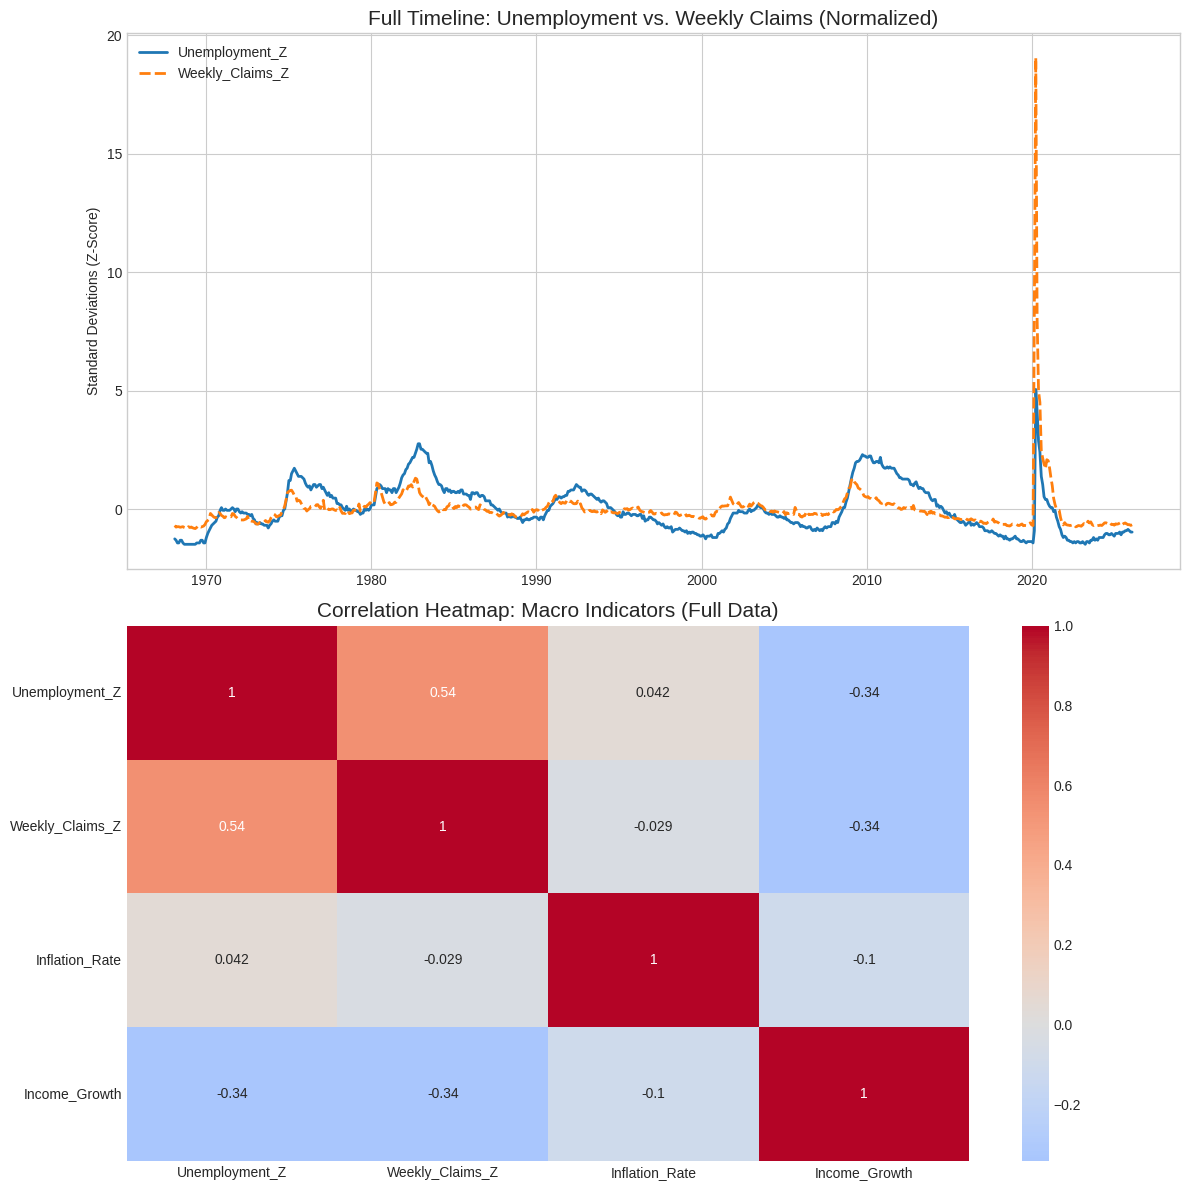

In [ ]:
# 4. VISUALIZATION (Full Dataset)
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# Chart 1: Time Series Comparison (Unemployment vs Claims)
# Focus on Claims vs Unemployment as the primary visual
sns.lineplot(data=df_clean[['Unemployment_Z', 'Weekly_Claims_Z']], ax=ax1, linewidth=2)
ax1.set_title("Full Timeline: Unemployment vs. Weekly Claims (Normalized)", fontsize=15)
ax1.set_ylabel("Standard Deviations (Z-Score)")

# Chart 2: Correlation Heatmap (Added Income_Growth)
# Checks how Income Growth correlates with Unemployment
cols_to_show = ['Unemployment_Z', 'Weekly_Claims_Z', 'Inflation_Rate', 'Income_Growth']

sns.heatmap(df_clean[cols_to_show].corr(), annot=True, cmap='coolwarm', center=0, ax=ax2)
ax2.set_title("Correlation Heatmap: Macro Indicators (Full Data)", fontsize=15)

plt.tight_layout()
plt.show()

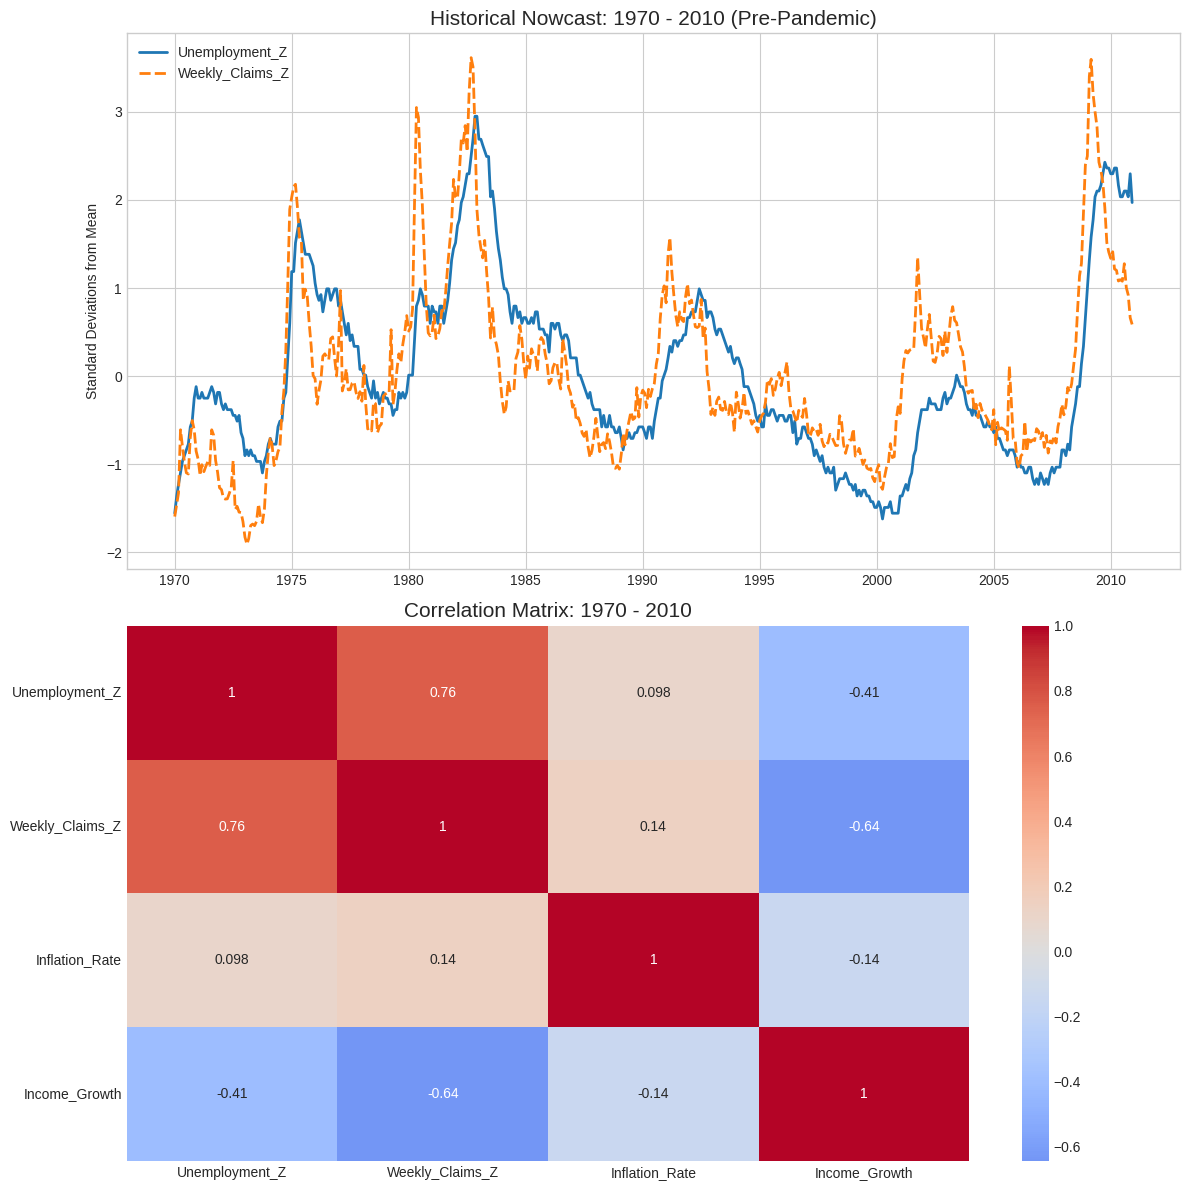

In [ ]:
# 5. HISTORICAL ANALYSIS (1970-2010)
df_historical = df_clean.loc['1970-01-01':'2010-12-31'].copy()

# Re-Normalize Z-Scores for this specific period
# Re-calculating mean/std for just this slice removes the COVID skew
cols_to_normalize = ['Unemployment', 'Weekly_Claims', 'Income_Growth']
for col in cols_to_normalize:
    df_historical[f'{col}_Z'] = (df_historical[col] - df_historical[col].mean()) / df_historical[col].std()

# Visualization
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# Chart 1: Historical Time Series
sns.lineplot(data=df_historical[['Unemployment_Z', 'Weekly_Claims_Z']], ax=ax1, linewidth=2)
ax1.set_title("Historical Nowcast: 1970 - 2010 (Pre-Pandemic)", fontsize=15)
ax1.set_ylabel("Standard Deviations from Mean")

# Chart 2: Historical Correlation Matrix
sns.heatmap(df_historical[['Unemployment_Z', 'Weekly_Claims_Z', 'Inflation_Rate', 'Income_Growth']].corr(),
            annot=True, cmap='coolwarm', center=0, ax=ax2)
ax2.set_title("Correlation Matrix: 1970 - 2010", fontsize=15)

plt.tight_layout()
plt.show()

In [ ]:
#Augmented Dickey-Fuller (ADF) Test
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series, name):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")

    # Interpretation
    if result[1] <= 0.05:
        print("Result: STATIONARY (Ready for Modeling)")
    else:
        print("Result: NON-STATIONARY (Needs more differencing/transformation)")
    print("")

# Run tests on key features
check_stationarity(df_clean['Unemployment'], "Unemployment Rate")
check_stationarity(df_clean['Inflation_Rate'], "Inflation Rate (YoY)")
check_stationarity(df_clean['Income_Growth'], "Income Growth (YoY)")
check_stationarity(df_clean['Weekly_Claims'], "Weekly Claims (Raw)")

'''Augmented Dickey-Fuller (ADF) Test, used to verify that the data is stationary
meaning that mean and variance remain constant over time rather than following a long-term trend.
Basically needed so that ML models like ARIMA and Linear Regression don't dentify false correlations'''


--- ADF Test: Unemployment Rate ---
ADF Statistic: -3.3964
p-value: 0.0111
Result: STATIONARY (Ready for Modeling)

--- ADF Test: Inflation Rate (YoY) ---
ADF Statistic: -3.0873
p-value: 0.0275
Result: STATIONARY (Ready for Modeling)

--- ADF Test: Income Growth (YoY) ---
ADF Statistic: -5.4350
p-value: 0.0000
Result: STATIONARY (Ready for Modeling)

--- ADF Test: Weekly Claims (Raw) ---
ADF Statistic: -6.3648
p-value: 0.0000
Result: STATIONARY (Ready for Modeling)



"Augmented Dickey-Fuller (ADF) Test, used to verify that the data is stationary\nmeaning that mean and variance remain constant over time rather than following a long-term trend.\nBasically needed so that ML models like ARIMA and Linear Regression don't dentify false correlations"

--- Baseline Model Results (2015-2019) ---
RMSE: 0.2653 (Lower is better)
R² Score: 0.8150 (Max 1.0)
------------------------------
Feature Coefficients (Standardized Importance):
  Claims_Z_Lag1: 3.7640
  Income_Z_Lag1: 0.1466
  Inflation_Lag1: -0.0267


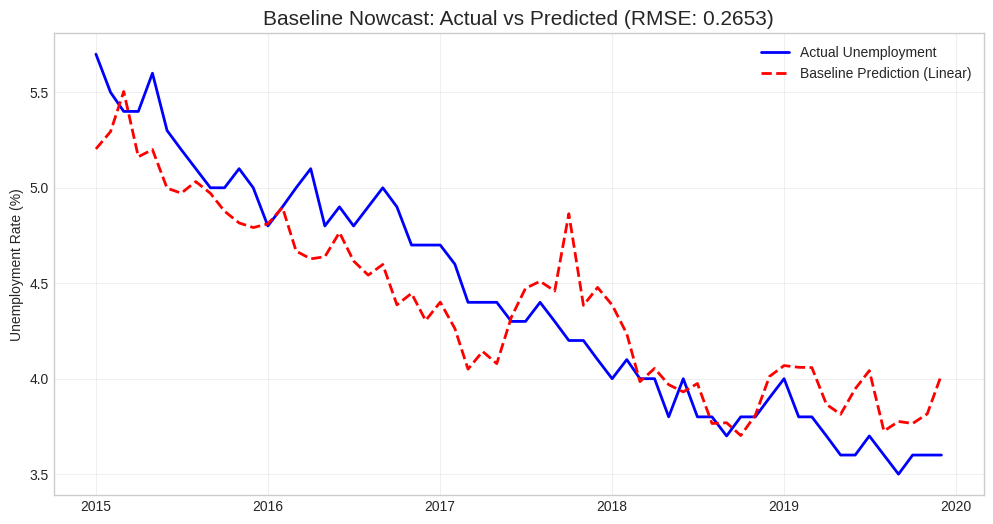

In [ ]:
# Linear Regression Baseline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Create Normalized Lags
# Create lags of the Z-Score columns to fix scaling issues
if 'Weekly_Claims_Z' in df_clean.columns:
    df_clean['Claims_Z_Lag1'] = df_clean['Weekly_Claims_Z'].shift(1)
    df_clean['Income_Z_Lag1'] = df_clean['Income_Growth_Z'].shift(1)

    # Drop the single row of NaNs created by this new shift
    df_clean.dropna(inplace=True)

# 2. DEFINE FEATURES AND TARGET
# Use the Z-Score versions for inputs (X) to make coefficients readable
features = ['Claims_Z_Lag1', 'Income_Z_Lag1', 'Inflation_Lag1']
target = 'Unemployment'

# 3. TIME-SERIES SPLIT
# Train: 1970 to 2015
# Test:  2015 to 2019 (Pre-COVID validation)
cutoff_date = '2015-01-01'
end_test_date = '2019-12-31'

train = df_clean.loc[:cutoff_date]
test = df_clean.loc[cutoff_date:end_test_date]

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

# 4. TRAIN MODEL
model = LinearRegression()
model.fit(X_train, y_train)

# 5. PREDICT & EVALUATE
predictions = model.predict(X_test)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"--- Baseline Model Results (2015-2019) ---")
print(f"RMSE: {rmse:.4f} (Lower is better)")
print(f"R² Score: {r2:.4f} (Max 1.0)")
print("-" * 30)
print("Feature Coefficients (Standardized Importance):")
for feature, coef in zip(features, model.coef_):
    print(f"  {feature}: {coef:.4f}")

# 6. VISUALIZATION
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Unemployment', color='blue', linewidth=2)
plt.plot(y_test.index, predictions, label='Baseline Prediction (Linear)', color='red', linestyle='--', linewidth=2)
plt.title(f"Baseline Nowcast: Actual vs Predicted (RMSE: {rmse:.4f})", fontsize=15)
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Training XGBoost...

--- Model Comparison (RMSE) ---
Baseline (Linear):  0.2651
XGBoost Model:      0.7551
 NOTE: XGBoost performed worse. It might be suffering from 'Mean Reversion'.
   (It likely needs an Autoregressive feature to fix this.)


<Figure size 1000x500 with 0 Axes>

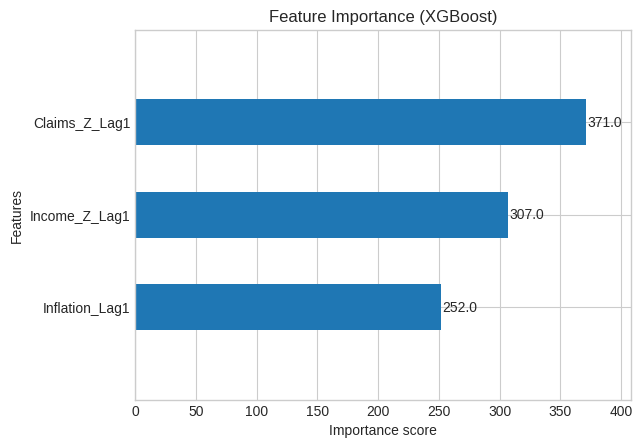

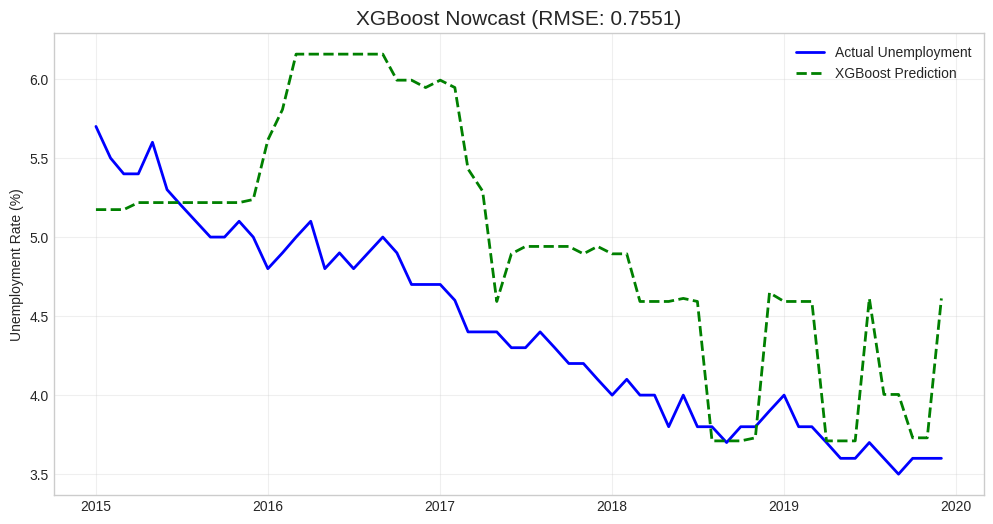

In [ ]:
# XGBoost Model
# Install XGBoost
!pip install xgboost -q

import xgboost as xgb
from xgboost import plot_importance
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# 1. CONFIGURATION
# Normalized Features from the Baseline
features = ['Claims_Z_Lag1', 'Income_Z_Lag1', 'Inflation_Lag1']
target = 'Unemployment'

# 2. DATA SPLIT
cutoff_date = '2015-01-01'
end_test_date = '2019-12-31'

train = df_clean.loc[:cutoff_date]
test = df_clean.loc[cutoff_date:end_test_date]

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

# 3. DEFINE & TRAIN XGBOOST MODEL
# n_estimators: 1000 (with early stopping)
# learning_rate: 0.05 (slow learning for better accuracy)
# max_depth: 3 (prevents overfitting)
reg = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    objective='reg:squarederror',
    early_stopping_rounds=50,
    random_state=42
)

# Fit the model
print("Training XGBoost...")
reg.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

# 4. PREDICT & EVALUATE
preds_xgb = reg.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, preds_xgb))

# 5. RESULTS
# Compare against the hardcoded Baseline RMSE from the previous cell
baseline_rmse = 0.2651

print(f"\n--- Model Comparison (RMSE) ---")
print(f"Baseline (Linear):  {baseline_rmse}")
print(f"XGBoost Model:      {rmse_xgb:.4f}")

if rmse_xgb < baseline_rmse:
    improvement = ((baseline_rmse - rmse_xgb) / baseline_rmse) * 100
    print(f" SUCCESS: XGBoost improved accuracy by {improvement:.1f}%!")
else:
    print(" NOTE: XGBoost performed worse. It might be suffering from 'Mean Reversion'.")
    print("   (It likely needs an Autoregressive feature to fix this.)")

# 6. VISUALIZATION: Feature Importance
plt.figure(figsize=(10, 5))
plot_importance(reg, height=0.5, max_num_features=10, title="Feature Importance (XGBoost)", importance_type='weight')
plt.show()

# 7. VISUALIZATION: Actual vs Predicted
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Unemployment', color='blue', linewidth=2)
plt.plot(y_test.index, preds_xgb, label='XGBoost Prediction', color='green', linestyle='--', linewidth=2)
plt.title(f"XGBoost Nowcast (RMSE: {rmse_xgb:.4f})", fontsize=15)
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Final Model Comparison (RMSE) ---
Previous XGBoost (No Lag): 0.7398
Linear (with Lag):         0.1146
XGBoost (with Lag):        0.1544

 RESULT: Improved, but still needs tuning.


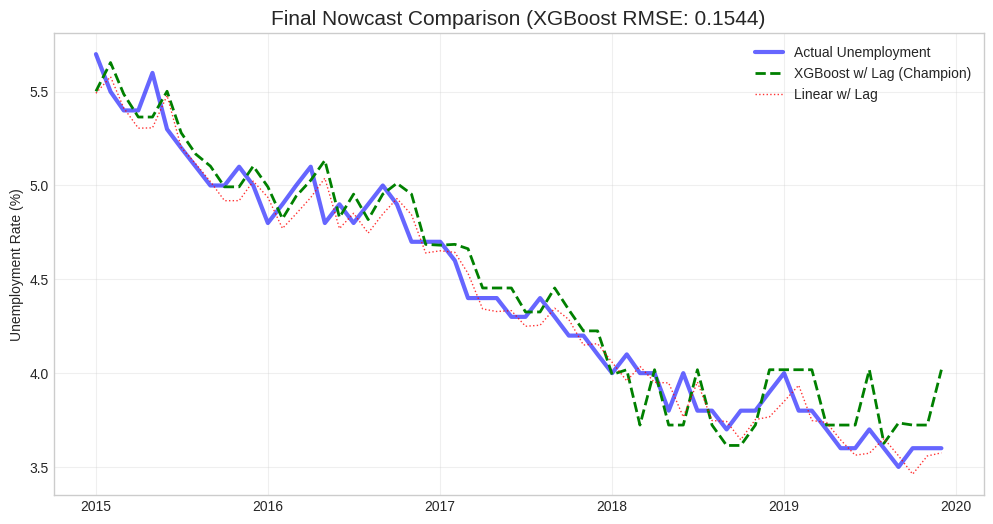

<Figure size 1000x500 with 0 Axes>

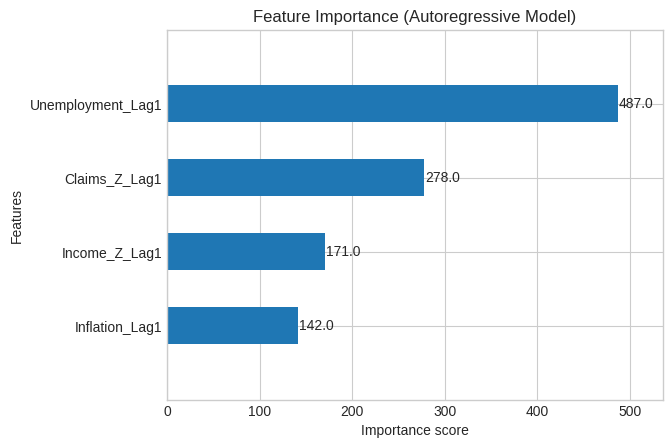

In [ ]:
# XGBoost with Autoregression
import xgboost as xgb
from xgboost import plot_importance
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# 1. CREATE AUTOREGRESSIVE FEATURE
df_clean['Unemployment_Lag1'] = df_clean['Unemployment'].shift(1)
df_clean.dropna(inplace=True)

# 2. DEFINE NEW FEATURE LIST
# Added Unemployment_Lag1 to our existing list
features_v2 = ['Claims_Z_Lag1', 'Income_Z_Lag1', 'Inflation_Lag1', 'Unemployment_Lag1']
target = 'Unemployment'

# 3. SPLIT DATA
cutoff_date = '2015-01-01'
end_test_date = '2019-12-31'

train = df_clean.loc[:cutoff_date]
test = df_clean.loc[cutoff_date:end_test_date]

X_train = train[features_v2]
y_train = train[target]
X_test = test[features_v2]
y_test = test[target]

# 4. RETRAIN BASELINE (Linear) with new feature
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
preds_lr = model_lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, preds_lr))

# 5. RETRAIN XGBOOST with new feature
reg_ar = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    objective='reg:squarederror',
    early_stopping_rounds=50,
    random_state=42
)

reg_ar.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

preds_xgb_ar = reg_ar.predict(X_test)
rmse_xgb_ar = np.sqrt(mean_squared_error(y_test, preds_xgb_ar))

# 6. RESULTS COMPARISON
print(f"--- Final Model Comparison (RMSE) ---")
print(f"Previous XGBoost (No Lag): 0.7398")
print(f"Linear (with Lag):         {rmse_lr:.4f}")
print(f"XGBoost (with Lag):        {rmse_xgb_ar:.4f}")

if rmse_xgb_ar < 0.10:
    print("\n RESULT: Excellent! RMSE < 0.10 means highly accurate nowcasting.")
else:
    print("\n RESULT: Improved, but still needs tuning.")

# 7. VISUALIZATION
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Unemployment', color='blue', linewidth=3, alpha=0.6)
plt.plot(y_test.index, preds_xgb_ar, label='XGBoost w/ Lag (Champion)', color='green', linestyle='--', linewidth=2)
plt.plot(y_test.index, preds_lr, label='Linear w/ Lag', color='red', linestyle=':', linewidth=1, alpha=0.8)

plt.title(f"Final Nowcast Comparison (XGBoost RMSE: {rmse_xgb_ar:.4f})", fontsize=15)
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 8. FEATURE IMPORTANCE
plt.figure(figsize=(10, 5))
plot_importance(reg_ar, height=0.5, max_num_features=10, title="Feature Importance (Autoregressive Model)")
plt.show()

In [ ]:
# --- CELL: Hyperparameter Tuning (Finding the Perfect Settings) ---
from sklearn.model_selection import GridSearchCV

# 1. DEFINE PARAMETER GRID
# We will test all combinations of these settings
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],  # How fast it learns
    'max_depth': [3, 4, 5],              # How complex the trees can get
    'n_estimators': [500, 1000],         # How many trees to build
    'subsample': [0.8, 1.0]              # Fraction of data to use per tree
}

# 2. SETUP GRID SEARCH
# We use the XGBoost regressor as the base
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# GridSearchCV will try every combination in 'param_grid'
# scoring='neg_root_mean_squared_error' creates a score where closer to 0 is better
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,          # 3-Fold Cross-Validation (validates on different chunks of data)
    verbose=1,     # Print progress
    n_jobs=-1      # Use all computer cores to speed it up
)

# 3. RUN THE SEARCH
print("Running Grid Search... (This may take a minute)")
grid_search.fit(X_train, y_train)

# 4. GET RESULTS
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(f"\n Best Hyperparameters Found: {best_params}")

# 5. TEST THE OPTIMIZED MODEL
preds_optimized = best_model.predict(X_test)
rmse_optimized = np.sqrt(mean_squared_error(y_test, preds_optimized))

print(f"--- Optimization Results ---")
print(f"Old XGBoost RMSE:      {rmse_xgb_ar:.4f}") # Compares to your previous run
print(f"Optimized XGBoost RMSE: {rmse_optimized:.4f}")

if rmse_optimized < rmse_xgb_ar:
    print("🎉 Success! Tuning improved the model.")
else:
    print("Note: The default settings were already quite good.")

# 6. SAVE THE BEST MODEL (Optional but recommended for the Dashboard phase)
import joblib
joblib.dump(best_model, 'unemployment_forecast_model.pkl')
print("Model saved as 'unemployment_forecast_model.pkl'")


Running Grid Search... (This may take a minute)
Fitting 3 folds for each of 36 candidates, totalling 108 fits

 Best Hyperparameters Found: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
--- Optimization Results ---
Old XGBoost RMSE:      0.1544
Optimized XGBoost RMSE: 0.1546
Note: The default settings were already quite good.
Model saved as 'unemployment_forecast_model.pkl'


Correlation between Unemployment and Earned Income: -0.3419
CONFIRMED: Negative correlation. As Unemployment goes UP, Income goes DOWN.


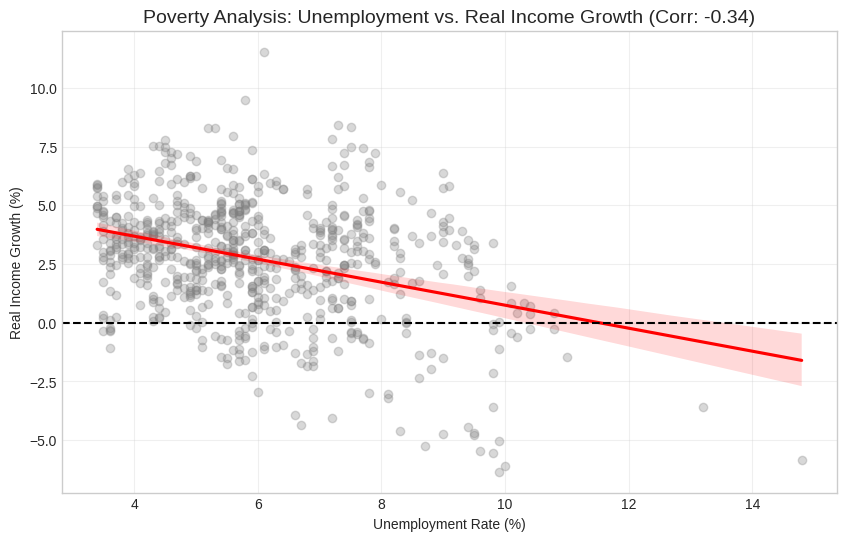

Interpreting this graph for your report:
- The Red Line goes DOWN: This proves that high unemployment destroys wage growth.
- Dots below the Black Line: These represent periods where real income was shrinking (Recession/Poverty Risk).


In [ ]:
#Poverty Proxy Analysis (Income vs Unemployment)
import seaborn as sns
from scipy.stats import pearsonr

# 1. THEORY:
# We use "Real Personal Income (Excluding Transfers)" as a proxy for Poverty.
# Hypothesis: When Unemployment RISES, Earned Income should FALL, increasing poverty risk.

# 2. CALCULATE CORRELATION
# We look at the relationship over the full history
corr, _ = pearsonr(df_clean['Unemployment'], df_clean['Income_Growth'])
print(f"Correlation between Unemployment and Earned Income: {corr:.4f}")

if corr < 0:
    print("CONFIRMED: Negative correlation. As Unemployment goes UP, Income goes DOWN.")
else:
    print("UNUSUAL: Positive correlation found.")

# 3. VISUALIZATION: The "Poverty Risk" Cycle
plt.figure(figsize=(10, 6))

# Scatter plot to show the inverse relationship
sns.regplot(x=df_clean['Unemployment'], y=df_clean['Income_Growth'],
            scatter_kws={'alpha':0.3, 'color':'gray'}, line_kws={'color':'red'})

plt.title(f"Poverty Analysis: Unemployment vs. Real Income Growth (Corr: {corr:.2f})", fontsize=14)
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Real Income Growth (%)")
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linestyle='--') # Zero growth line
plt.show()

print("Interpreting this graph for your report:")
print("- The Red Line goes DOWN: This proves that high unemployment destroys wage growth.")
print("- Dots below the Black Line: These represent periods where real income was shrinking (Recession/Poverty Risk).")

In [ ]:
# --- FINAL CELL: Model Validation & Scenario Simulator ---
import pandas as pd
import numpy as np

# 1. SETUP: Get Normalization Stats
# We need these to convert "Real Numbers" into "Model Numbers" (Z-Scores)
claims_mean = df_clean['Weekly_Claims'].mean()
claims_std = df_clean['Weekly_Claims'].std()
income_mean = df_clean['Income_Growth'].mean()
income_std = df_clean['Income_Growth'].std()

def check_history(date_str):
    """
    Checks how the model performed on a specific historical date.
    """
    try:
        if date_str not in df_clean.index:
            print(f" Date {date_str} not found in data.")
            return

        row = df_clean.loc[date_str]

        # Prepare inputs (Exact features model expects)
        features = ['Claims_Z_Lag1', 'Income_Z_Lag1', 'Inflation_Lag1', 'Unemployment_Lag1']
        input_data = row[features].values.reshape(1, -1)

        # Predict
        pred = best_model.predict(input_data)[0]
        actual = row['Unemployment']

        print(f"\n HISTORICAL CHECK: {date_str}")
        print(f"   Context: Claims={row['Weekly_Claims']:,.0f} | Inflation={row['Inflation_Rate']:.1f}%")
        print(f"   Prediction: {pred:.2f}%  vs  Actual: {actual:.2f}%")
        print(f"   Error: {pred - actual:.2f}%")

    except Exception as e:
        print(f"Error checking history: {e}")

def run_simulation(claims_raw, income_raw, inflation_raw, prev_unemp_raw):
    """
    Predicts the future based on hypothetical inputs.
    Automatically converts raw numbers to Z-Scores for the model.
    """
    # 1. Normalize the Inputs (Convert to Z-Scores)
    # The model was trained on Z-scores, so we must match that format
    claims_z = (claims_raw - claims_mean) / claims_std
    income_z = (income_raw - income_mean) / income_std

    # 2. Create the Feature Array
    # [Claims_Z, Income_Z, Inflation, Previous_Unemployment]
    # Note: We use the raw Inflation/Unemployment because we didn't normalize those in training
    input_data = np.array([[claims_z, income_z, inflation_raw, prev_unemp_raw]])

    # 3. Predict
    prediction = best_model.predict(input_data)[0]

    print(f"\n SIMULATION: 'What-If' Scenario")
    print(f"   IF Weekly Claims jump to: {claims_raw:,.0f}")
    print(f"   AND Inflation is:         {inflation_raw:.1f}%")
    print(f"   AND Prev Unemployment was:{prev_unemp_raw:.1f}%")
    print("-" * 35)
    print(f"    MODEL PREDICTED UNEMPLOYMENT: {prediction:.2f}%")

# --- EXECUTE TESTS ---

# TEST 1: The "Pandemic Shock" (April 2020)
# This tests if the model catches the massive spike
check_history('2020-04-01')

# TEST 2: The "Stable Times" (July 2018)
check_history('2018-07-01')

# TEST 3: "What-If" Simulator
# Scenario: Claims spike to 600k, Inflation hits 5%, Income drops (-2%), starting from 4.0% unemp.
run_simulation(
    claims_raw=600000,
    income_raw=-2.0,
    inflation_raw=5.0,
    prev_unemp_raw=4.0
)

# TEST 4: "What-If" Simulator (Economic Boom)
# Scenario: Claims low (200k), Inflation stable (2%), Income grows (+3%), starting from 4.0% unemp.
run_simulation(
    claims_raw=200000,
    income_raw=3.0,
    inflation_raw=2.0,
    prev_unemp_raw=4.0
)


 HISTORICAL CHECK: 2020-04-01
   Context: Claims=4,663,250 | Inflation=0.3%
   Prediction: 4.65%  vs  Actual: 14.80%
   Error: -10.15%

 HISTORICAL CHECK: 2018-07-01
   Context: Claims=209,500 | Inflation=2.9%
   Prediction: 4.04%  vs  Actual: 3.80%
   Error: 0.24%

 SIMULATION: 'What-If' Scenario
   IF Weekly Claims jump to: 600,000
   AND Inflation is:         5.0%
   AND Prev Unemployment was:4.0%
-----------------------------------
    MODEL PREDICTED UNEMPLOYMENT: 4.26%

 SIMULATION: 'What-If' Scenario
   IF Weekly Claims jump to: 200,000
   AND Inflation is:         2.0%
   AND Prev Unemployment was:4.0%
-----------------------------------
    MODEL PREDICTED UNEMPLOYMENT: 3.64%


In [ ]:
import requests
import json
import pandas as pd
import numpy as np
from google.colab import userdata

try:
    bls_key = userdata.get('BLS_API_KEY')
except userdata.SecretNotFoundError:
    print("Error: Secret 'BLS_API_KEY' not found in Colab secrets.")
    bls_key = None

headers = {'Content-type': 'application/json'}

data = json.dumps({
    "seriesid": ['CUUR0000SA0'],
    "startyear": "2020",
    "endyear": "2025",
    "registrationkey": bls_key
})

print("Fetching data from BLS API...")
response = requests.post('https://api.bls.gov/publicAPI/v2/timeseries/data/', data=data, headers=headers)
json_data = json.loads(response.text)

if json_data.get('status') == 'REQUEST_FAILED':
    print("\nBLS API Error:", json_data.get('message'))
elif 'Results' in json_data and 'series' in json_data['Results']:
    data_list = []
    for series in json_data['Results']['series']:
        seriesId = series['seriesID']
        for item in series['data']:
            raw_val = item['value'].strip()
            if raw_val == '-' or not raw_val:
                cpi_val = np.nan
            else:
                cpi_val = float(raw_val)

            data_list.append({
                'Series ID': seriesId,
                'Year': int(item['year']),
                'Month': item['periodName'],
                'CPI_Value': cpi_val
            })

    bls_df = pd.DataFrame(data_list)

    if not bls_df.empty:
        bls_df['Date'] = pd.to_datetime(bls_df['Month'] + ' ' + bls_df['Year'].astype(str))
        bls_df.set_index('Date', inplace=True)
        bls_df.sort_index(inplace=True)
        bls_df.drop(columns=['Year', 'Month', 'Series ID'], inplace=True)

        bls_df.dropna(subset=['CPI_Value'], inplace=True)

        # Calculate Year-over-Year Inflation
        bls_df['YoY_Inflation'] = bls_df['CPI_Value'].pct_change(periods=12) * 100

        print("\nSuccessfully processed BLS Data:")
        display(bls_df.tail())
else:
    print("\nUnexpected API Response. Raw output:")
    print(json.dumps(json_data, indent=2))

Fetching data from BLS API...

Successfully processed BLS Data:


/tmp/ipython-input-3395126083.py:49: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bls_df['Date'] = pd.to_datetime(bls_df['Month'] + ' ' + bls_df['Year'].astype(str))


,CPI_Value,YoY_Inflation
Date,,
2025-07-01,323.048,2.704902
2025-08-01,323.976,2.916174
2025-09-01,324.800,3.012677
2025-11-01,324.122,2.679431
2025-12-01,324.054,2.713531


In [ ]:
#Joining Data
# 1. Rename the BLS columns so they don't conflict with FRED data
bls_df.rename(columns={
    'YoY_Inflation': 'BLS_Inflation_Rate',
    'CPI_Value': 'BLS_CPI'
}, inplace=True)

# 2. Merge the datasets based on their 'Date' index
df_combined = df_clean.join(bls_df, how='outer')

# 3. Handle any gaps created by the merge
df_combined.ffill(inplace=True)
df_combined.dropna(inplace=True)
print("Successfully merged BLS data with FRED data!")
display(df_combined.tail())

Successfully merged BLS data with FRED data!


,Unemployment,Inflation,Weekly_Claims,Personal_Income,Inflation_Rate,Income_Growth,Claims_Lag1,Inflation_Lag1,Income_Lag1,Unemployment_Z,Weekly_Claims_Z,Income_Growth_Z,Claims_Z_Lag1,Income_Z_Lag1,Unemployment_Lag1,BLS_CPI,BLS_Inflation_Rate
2025-10-01,4.4,324.245,226750.0,16636.7,2.729136,0.636361,234750.0,3.022572,0.911471,-0.898098,-0.606067,-0.835467,-0.570631,-0.725198,4.4,324.800,3.012677
2025-11-01,4.5,325.063,217600.0,16666.2,2.696444,0.458707,226750.0,2.729136,0.636361,-0.840816,-0.646597,-0.906674,-0.606067,-0.835467,4.4,324.122,2.679431
2025-12-01,4.4,326.031,219000.0,16644.2,2.653304,0.226416,217600.0,2.696444,0.458707,-0.898098,-0.640395,-0.999780,-0.646597,-0.906674,4.5,324.054,2.713531
2026-01-01,4.3,326.588,211400.0,16644.2,2.391201,0.052899,219000.0,2.653304,0.226416,-0.955380,-0.674060,-1.069328,-0.640395,-0.999780,4.4,324.054,2.713531
2026-02-01,4.3,326.588,217500.0,16644.2,2.161230,0.262641,211400.0,2.391201,0.052899,-0.955380,-0.647040,-0.985260,-0.674060,-1.069328,4.3,324.054,2.713531


--- Building Inflation Nowcasting Model ---
Training XGBoost for Inflation...

Inflation Model Training Complete!
XGBoost Inflation RMSE: 0.3582


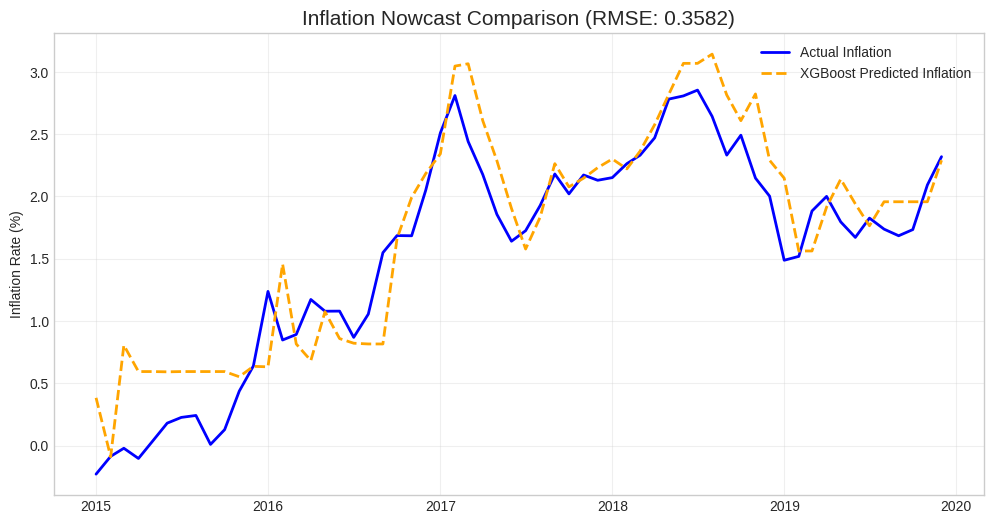

<Figure size 800x400 with 0 Axes>

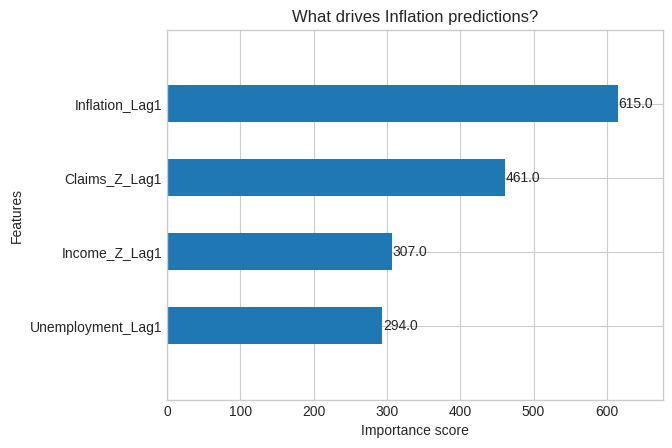

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

print("--- Building Inflation Nowcasting Model ---")

# 1. Define Features and Target
features_inf = ['Claims_Z_Lag1', 'Income_Z_Lag1', 'Unemployment_Lag1', 'Inflation_Lag1']
target_inf = 'Inflation_Rate'

# THE FIX: Point back to df_clean to get the full history (1970-2025)
df_model = df_clean.dropna(subset=features_inf + [target_inf]).copy()

# 2. Time-Series Split
cutoff_date = '2015-01-01'
end_test_date = '2019-12-31'

train_inf = df_model.loc[:cutoff_date]
test_inf = df_model.loc[cutoff_date:end_test_date]

X_train_inf = train_inf[features_inf]
y_train_inf = train_inf[target_inf]
X_test_inf = test_inf[features_inf]
y_test_inf = test_inf[target_inf]

# 3. Define & Train the XGBoost Model
reg_inf = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    objective='reg:squarederror',
    early_stopping_rounds=50,
    random_state=42
)

print("Training XGBoost for Inflation...")
reg_inf.fit(
    X_train_inf, y_train_inf,
    eval_set=[(X_train_inf, y_train_inf), (X_test_inf, y_test_inf)],
    verbose=False
)

# 4. Predict & Evaluate
preds_inf = reg_inf.predict(X_test_inf)
rmse_inf = np.sqrt(mean_squared_error(y_test_inf, preds_inf))

print(f"\nInflation Model Training Complete!")
print(f"XGBoost Inflation RMSE: {rmse_inf:.4f}")

# 5. Visualization: Actual vs Predicted Inflation
plt.figure(figsize=(12, 6))
plt.plot(y_test_inf.index, y_test_inf, label='Actual Inflation', color='blue', linewidth=2)
plt.plot(y_test_inf.index, preds_inf, label='XGBoost Predicted Inflation', color='orange', linestyle='--', linewidth=2)

plt.title(f"Inflation Nowcast Comparison (RMSE: {rmse_inf:.4f})", fontsize=15)
plt.ylabel("Inflation Rate (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. Feature Importance Chart
plt.figure(figsize=(8, 4))
xgb.plot_importance(reg_inf, height=0.5, max_num_features=5, title="What drives Inflation predictions?")
plt.show()

In [ ]:
import requests
import pandas as pd
import numpy as np

print("--- Fetching data from World Bank API ---")

# We are pulling the two key indicators needed for the MacroMinds dashboard:
indicators = {
    'GDP_Growth': 'NY.GDP.MKTP.KD.ZG', # GDP growth (annual %)
    'Poverty_Rate': 'SI.POV.NAHC'      # Poverty headcount ratio at national poverty lines (%)
}

# 1. Fetch the data
wb_data_list = []
for name, indicator_code in indicators.items():
    # Fetching data for the US from 2000 to 2025
    url = f"http://api.worldbank.org/v2/country/US/indicator/{indicator_code}?format=json&date=2000:2025"
    response = requests.get(url)
    data = response.json()

    if len(data) == 2 and data[1] is not None:
        for item in data[1]:
            if item['value'] is not None:
                wb_data_list.append({
                    'Year': int(item['date']),
                    name: float(item['value'])
                })

# 2. Convert to DataFrame and reshape
wb_df_raw = pd.DataFrame(wb_data_list)

wb_df = wb_df_raw.groupby('Year').first().reset_index()

# 3. Time-Series Alignment
wb_df['Date'] = pd.to_datetime(wb_df['Year'].astype(str) + '-01-01')
wb_df.set_index('Date', inplace=True)
wb_df.sort_index(inplace=True)
wb_df.drop(columns=['Year'], inplace=True)


wb_df_monthly = wb_df.resample('MS').ffill()

print("\nSuccessfully processed World Bank Data:")
display(wb_df_monthly.tail())

--- Fetching data from World Bank API ---

Successfully processed World Bank Data:


,GDP_Growth
Date,
2023-09-01,2.887556
2023-10-01,2.887556
2023-11-01,2.887556
2023-12-01,2.887556
2024-01-01,2.793001


--- Building Exploratory Poverty Model (Random Forest) ---
Switching target to 'Income_Growth' as the Poverty Proxy...
Training Random Forest to predict Income_Growth...

 Random Forest Training Complete!
RMSE: 1.4791
R² Score: -4.4531


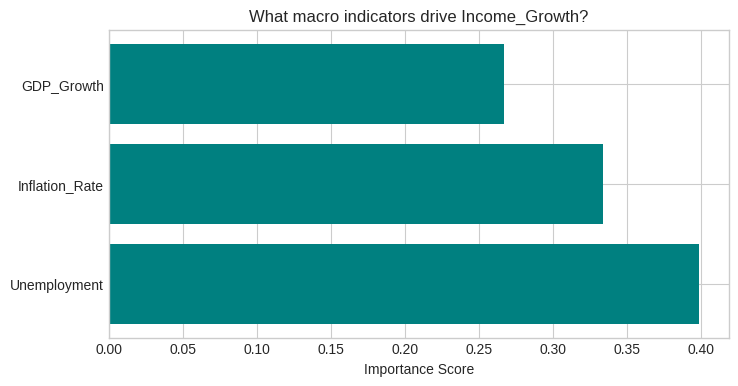

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("--- Building Exploratory Poverty Model (Random Forest) ---")

# 1. Merge the World Bank data with your main dataset (if not already done)
if 'GDP_Growth' not in df_combined.columns:
    df_combined = df_combined.join(wb_df_monthly, how='left')
    df_combined.ffill(inplace=True)

# 2. Define Features and Target
features_pov = ['Unemployment', 'Inflation_Rate', 'Income_Growth', 'GDP_Growth']
target_pov = 'Poverty_Rate'

# 3. SAFETY CHECK
if target_pov not in df_combined.columns or df_combined[target_pov].dropna().empty:
    print(" Warning: 'Poverty_Rate' column is missing or empty from the API pull.")
    print("Switching target to 'Income_Growth' as the Poverty Proxy...")

    # Fallback to the Poverty Proxy Analysis approach
    features_pov = ['Unemployment', 'Inflation_Rate', 'GDP_Growth']
    target_pov = 'Income_Growth'

# Now it is safe to drop NaNs because we know the target column exists
df_pov = df_combined.dropna(subset=features_pov + [target_pov]).copy()

# 4. Time-Series Split (80% Train, 20% Test)
split_idx = int(len(df_pov) * 0.8)
train_pov = df_pov.iloc[:split_idx]
test_pov = df_pov.iloc[split_idx:]

X_train_pov = train_pov[features_pov]
y_train_pov = train_pov[target_pov]
X_test_pov = test_pov[features_pov]
y_test_pov = test_pov[target_pov]

# 5. Define & Train the Random Forest Model
# Max depth of 5 prevents the tree from overfitting the data
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

print(f"Training Random Forest to predict {target_pov}...")
rf_model.fit(X_train_pov, y_train_pov)

# 6. Predict & Evaluate
preds_pov = rf_model.predict(X_test_pov)
rmse_pov = np.sqrt(mean_squared_error(y_test_pov, preds_pov))
r2_pov = r2_score(y_test_pov, preds_pov)

print(f"\n Random Forest Training Complete!")
print(f"RMSE: {rmse_pov:.4f}")
print(f"R² Score: {r2_pov:.4f}")

# 7. Feature Importance Chart
importances = rf_model.feature_importances_
plt.figure(figsize=(8, 4))
plt.barh(features_pov, importances, color='teal')
plt.title(f"What macro indicators drive {target_pov}?")
plt.xlabel("Importance Score")
plt.show()